# **Exploratory Data Analysis (EDA) - Skripsi Sistem Isyarat Bahasa Indonesia (SIBI)**

Notebook ini dirancang secara komprehensif untuk tahapan **Exploratory Data Analysis (EDA)** pada penelitian skripsi yang menggunakan dataset citra bahasa isyarat. 

**Dataset Sumber:** [Labeled Official Indonesian Sign Language (SIBI) Alphabet](https://data.mendeley.com/datasets/yhsgmynccf/1)

**Tujuan Notebook:**
1. Validasi integritas struktur folder dan pasangan citra-label.
2. Analisis keseimbangan distribusi kelas untuk memastikan model tidak *bias*.
3. Pengecekan dimensi spasial untuk kebutuhan standardisasi input arsitektur *Deep Learning*.
4. Komparasi karakteristik visual dari variasi latar belakang dan augmentasi.
5. Verifikasi fitur anatomis menggunakan ekstraksi landmark tangan (MediaPipe).
6. Pemetaan distribusi letak objek dominan (Heatmap Posisi Tangan).
7. Evaluasi intensitas cahaya guna mengetahui tingkat kesulitan kondisi iluminasi dataset.


## **0. Setup & Import Libraries**
Memuat seluruh pustaka dasar yang dibutuhkan untuk komputasi, visualisasi, dan pemrosesan citra.


In [1]:
# Import Library & Setup Path
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import string

# Mengabaikan peringatan agar output notebook tetap bersih
import warnings
warnings.filterwarnings('ignore')

# Supaya plot matplotlib tampil proporsional di dalam notebook
%matplotlib inline

# Set style untuk visualisasi agar terlihat elegan (cocok untuk laporan skripsi)
sns.set_theme(style="whitegrid", palette="muted")


## **1. Konfigurasi Path & Struktur Direktori**
Menentukan direktori utama dataset dan mendefinisikan variasi data yang akan dianalisis.


In [2]:
# Path relatif dari folder 'notebook' ke folder 'data'
BASE_DATA_DIR = '../data'

# Daftar keempat dataset sesuai struktur folder Anda
datasets = [
    'sibi_alphabet_mono_bg_no_augmentation',
    'sibi_alphabet_mono_bg_with_augmentation',
    'sibi_alphabet_multi_bg_no_augmentation',
    'sibi_alphabet_multi_bg_with_augmentation'
]

splits = ['train', 'val', 'test']

print("Library siap. Path utama diatur ke:", BASE_DATA_DIR)
print(f"Direktori Proyek Utama: {BASE_DATA_DIR}")
print(f"Direktori Dataset: {BASE_DATA_DIR}")
print("Setup path berhasil!")


Library siap. Path utama diatur ke: ../data
Direktori Proyek Utama: ../data
Direktori Dataset: ../data
Setup path berhasil!


## **2. Rekapitulasi Jumlah Data Keseluruhan**
Menghitung seluruh baris data (gambar dan label teksnya) di setiap folder `train`, `val`, dan `test` untuk keempat variasi dataset guna memastikan tidak ada data yang *corrupt* atau hilang. Ini adalah langkah *sanity check* yang krusial sebelum masuk tahap *training*.


,Tipe Dataset,Split,Jml Gambar,Jml Label,Status
0,mono_bg_no_augmentation,TRAIN,1215,1215,Aman
1,mono_bg_no_augmentation,VAL,150,150,Aman
2,mono_bg_no_augmentation,TEST,75,75,Aman
3,mono_bg_with_augmentation,TRAIN,3645,3645,Aman
4,mono_bg_with_augmentation,VAL,150,150,Aman
5,mono_bg_with_augmentation,TEST,75,75,Aman
6,multi_bg_no_augmentation,TRAIN,6120,6120,Aman
7,multi_bg_no_augmentation,VAL,720,720,Aman
8,multi_bg_no_augmentation,TEST,360,360,Aman
9,multi_bg_with_augmentation,TRAIN,18359,18360,Selisih!


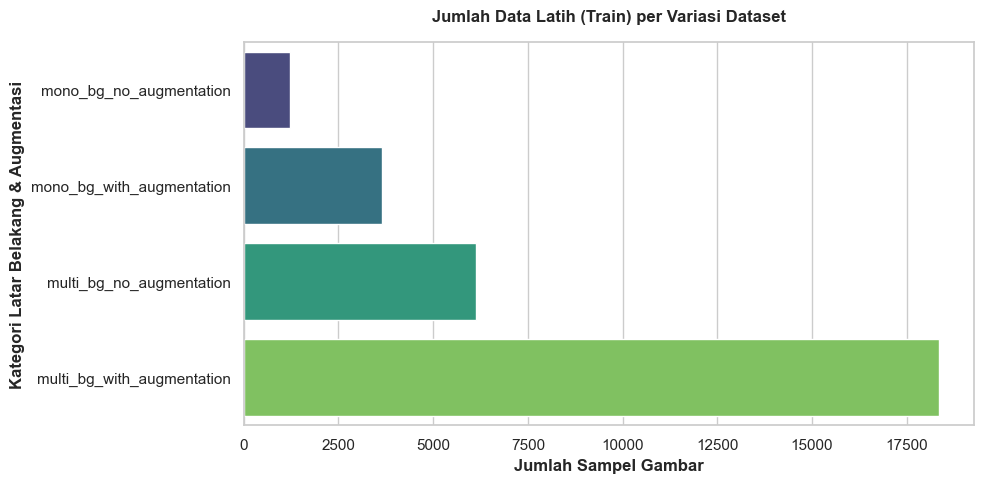

In [3]:
rekap_data = []

for ds in datasets:
    for split in splits:
        img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
        lbl_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', split)
        
        # Gunakan '**' dan recursive=True agar bisa masuk ke sub-folder (seperti folder A, B, dst)
        img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
        lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
        
        # Filter tambahan untuk memastikan yang terhitung hanya file, bukan nama folder
        img_files = [f for f in img_files if os.path.isfile(f)]
        lbl_files = [f for f in lbl_files if os.path.isfile(f)]
        
        rekap_data.append({
            'Tipe Dataset': ds.replace('sibi_alphabet_', ''),
            'Split': split.upper(),
            'Jml Gambar': len(img_files),
            'Jml Label': len(lbl_files),
            'Status': 'Aman' if len(img_files) == len(lbl_files) else 'Selisih!'
        })

df_rekap = pd.DataFrame(rekap_data)

# Tampilkan tabel rekapitulasi lengkap
display(df_rekap)

# Visualisasi ringkasan jumlah gambar per dataset (hanya data Train)
df_train = df_rekap[df_rekap['Split'] == 'TRAIN']
plt.figure(figsize=(10, 5))
sns.barplot(data=df_train, x='Jml Gambar', y='Tipe Dataset', palette='viridis')
plt.title('Jumlah Data Latih (Train) per Variasi Dataset', fontweight='bold', pad=15)
plt.xlabel('Jumlah Sampel Gambar', fontweight='bold')
plt.ylabel('Kategori Latar Belakang & Augmentasi', fontweight='bold')
plt.tight_layout()
plt.show()


## **3. Pengecekan Keseimbangan Kelas (*Class Balance*)**
Menganalisis distribusi frekuensi masing-masing kelas (huruf A-Z) pada setiap variasi dataset. Kelas yang tidak seimbang (*imbalanced*) dapat menyebabkan model bias terhadap kelas mayoritas.


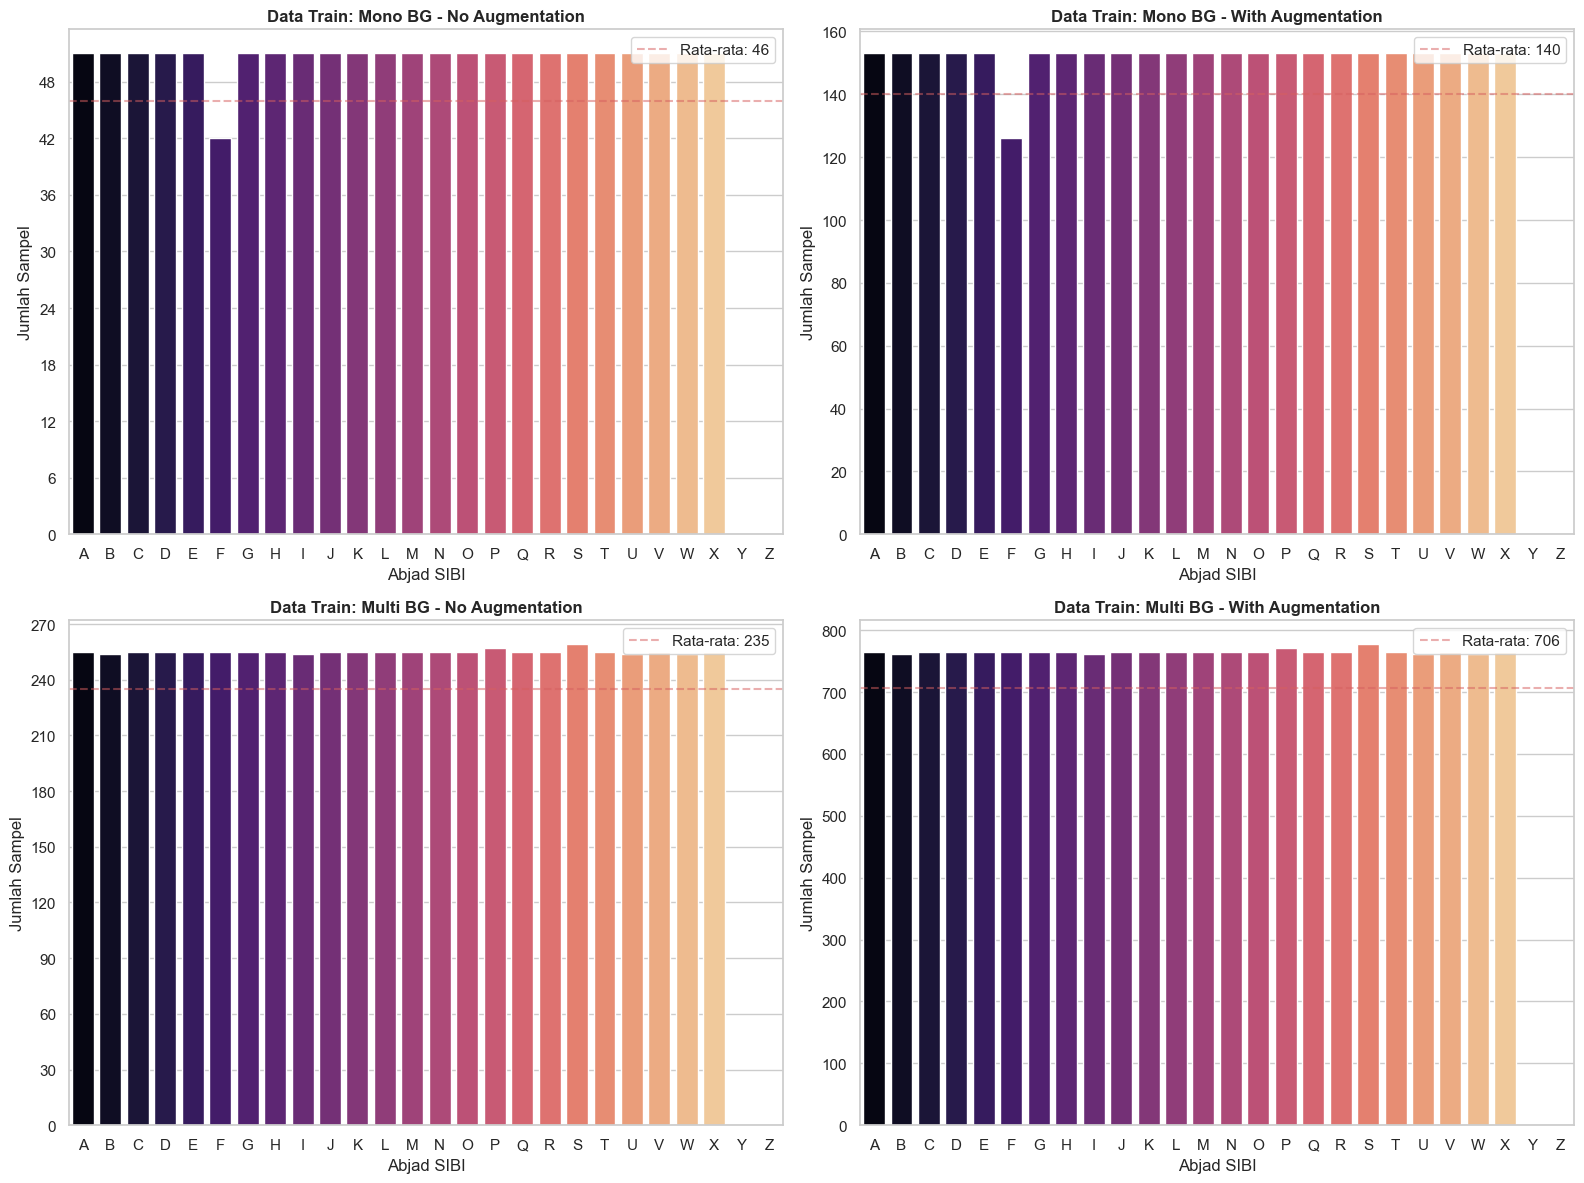

In [4]:
import string
import matplotlib.ticker as ticker

# Membuat pemetaan kelas dari 0-25 ke A-Z (Sesuai format YOLO)
alphabet = list(string.ascii_uppercase)
class_mapping = {i: letter for i, letter in enumerate(alphabet)}

# Siapkan kanvas 2x2 untuk 4 plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

titles = [
    'Mono BG - No Augmentation', 
    'Mono BG - With Augmentation',
    'Multi BG - No Augmentation', 
    'Multi BG - With Augmentation'
]

# Loop untuk menghitung dan mengeplot masing-masing dataset
for idx, ds in enumerate(datasets):
    target_label_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', 'train')
    
    # Pencarian rekursif untuk masuk ke sub-folder kelas
    label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
    label_files = [f for f in label_files if os.path.isfile(f)]
    
    class_counts = {letter: 0 for letter in alphabet}
    
    # Hitung frekuensi per kelas
    for txt_file in label_files:
        with open(txt_file, 'r') as f:
            for line in f.readlines():
                if line.strip():
                    try:
                        # Ambil ID kelas (angka paling pertama pada format YOLO)
                        class_id = int(line.split()[0])
                        if class_id in class_mapping:
                            class_counts[class_mapping[class_id]] += 1
                    except ValueError:
                        continue # Abaikan baris yang bukan angka
                        
    # Konversi ke DataFrame
    df_classes = pd.DataFrame(list(class_counts.items()), columns=['Abjad', 'Frekuensi'])
    
    # Plotting ke subplot yang sesuai
    sns.barplot(ax=axes[idx], data=df_classes, x='Abjad', y='Frekuensi', palette='magma')
    
    # Percantik tampilan masing-masing subplot
    axes[idx].set_title(f'Data Train: {titles[idx]}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Abjad SIBI')
    axes[idx].set_ylabel('Jumlah Sampel')
    
    # Tambahkan garis horizontal penanda rata-rata
    if not df_classes['Frekuensi'].sum() == 0:
        mean_freq = int(df_classes['Frekuensi'].mean())
        axes[idx].axhline(y=mean_freq, color='r', linestyle='--', alpha=0.5, 
                          label=f'Rata-rata: {mean_freq}')
        axes[idx].legend(loc='upper right')
        
    # Format sumbu Y agar tidak desimal
    axes[idx].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Sesuaikan jarak antar plot
plt.tight_layout()
plt.show()

# Beri peringatan jika ada dataset yang kosong
for ds in datasets:
    target_label_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', 'train')
    label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
    if not label_files:
        print(f"Peringatan: Tidak ditemukan file label di '{ds}'. Pastikan path sudah benar.")


## **4. Analisis Dimensi Resolusi Citra**
Langkah ini bertujuan untuk mengetahui apakah resolusi citra dalam dataset sudah seragam atau bervariasi. Informasi ini penting untuk menentukan nilai parameter ukuran input saat membangun arsitektur model (misal: *resize* ke $224 \times 224$).


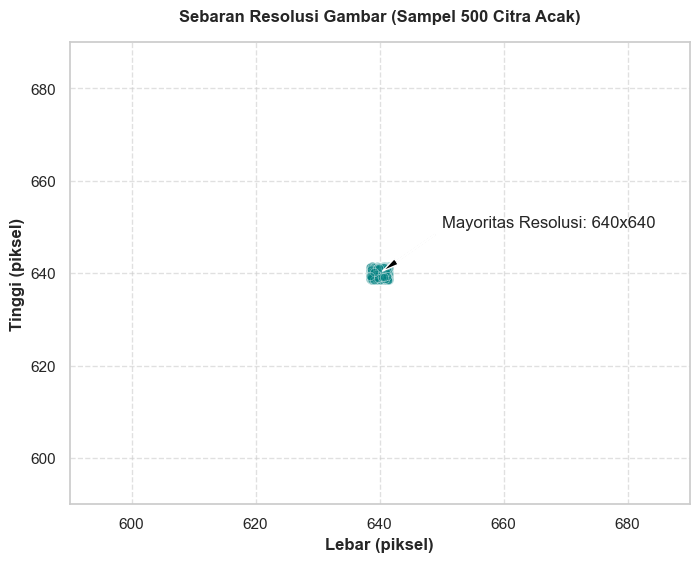

Informasi Resolusi:
- Rata-rata: 640 x 640 piksel.
- Resolusi Paling Sering Muncul (Mode): 640 x 640 piksel.


In [5]:
import random

# Ambil sampel acak dari dataset multi_bg_no_augmentation untuk mengecek dimensi
sample_img_dir = os.path.join(BASE_DATA_DIR, datasets[2], 'images', 'train')

# Pencarian rekursif untuk masuk ke sub-folder
all_sample_files = glob.glob(os.path.join(sample_img_dir, '**', '*.*'), recursive=True)
all_sample_files = [f for f in all_sample_files if os.path.isfile(f)]

widths = []
heights = []

# Ambil sampel secara acak agar memori tidak penuh dan komputasi lebih efisien
sample_size = min(500, len(all_sample_files))
if sample_size > 0:
    sample_files = random.sample(all_sample_files, sample_size)
else:
    sample_files = []

for img_path in sample_files:
    img = cv2.imread(img_path)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

# Tambahkan sedikit jitter (noise acak) agar titik scatter yang identik tidak bertumpuk
# Ini mempermudah pengamatan kepadatan titik resolusi
widths_jittered = [w + random.uniform(-1.5, 1.5) for w in widths]
heights_jittered = [h + random.uniform(-1.5, 1.5) for h in heights]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=widths_jittered, y=heights_jittered, alpha=0.5, color='teal')
plt.title(f'Sebaran Resolusi Gambar (Sampel {sample_size} Citra Acak)', fontweight='bold', pad=15)
plt.xlabel('Lebar (piksel)', fontweight='bold')
plt.ylabel('Tinggi (piksel)', fontweight='bold')

# Atur skala axis agar titiknya terlihat jelas meski resolusinya sama semua
if widths and heights:
    plt.xlim(min(widths) - 50, max(widths) + 50)
    plt.ylim(min(heights) - 50, max(heights) + 50)
    
    # Anotasi Resolusi Mayoritas
    mode_w = max(set(widths), key=widths.count)
    mode_h = max(set(heights), key=heights.count)
    plt.annotate(f'Mayoritas Resolusi: {mode_w}x{mode_h}', 
                 xy=(mode_w, mode_h), xytext=(mode_w+10, mode_h+10),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Kesimpulan teks
if widths and heights:
    print(f"Informasi Resolusi:")
    print(f"- Rata-rata: {int(np.mean(widths))} x {int(np.mean(heights))} piksel.")
    print(f"- Resolusi Paling Sering Muncul (Mode): {mode_w} x {mode_h} piksel.")
else:
    print("Peringatan: Tidak ada gambar yang berhasil terbaca.")


## **5. Visualisasi Komparatif 4 Variasi Dataset**
Menarik sampel acak dan membandingkan secara visual perbedaan nyata antara *mono background*, *multi background*, tanpa augmentasi, dan dengan augmentasi.


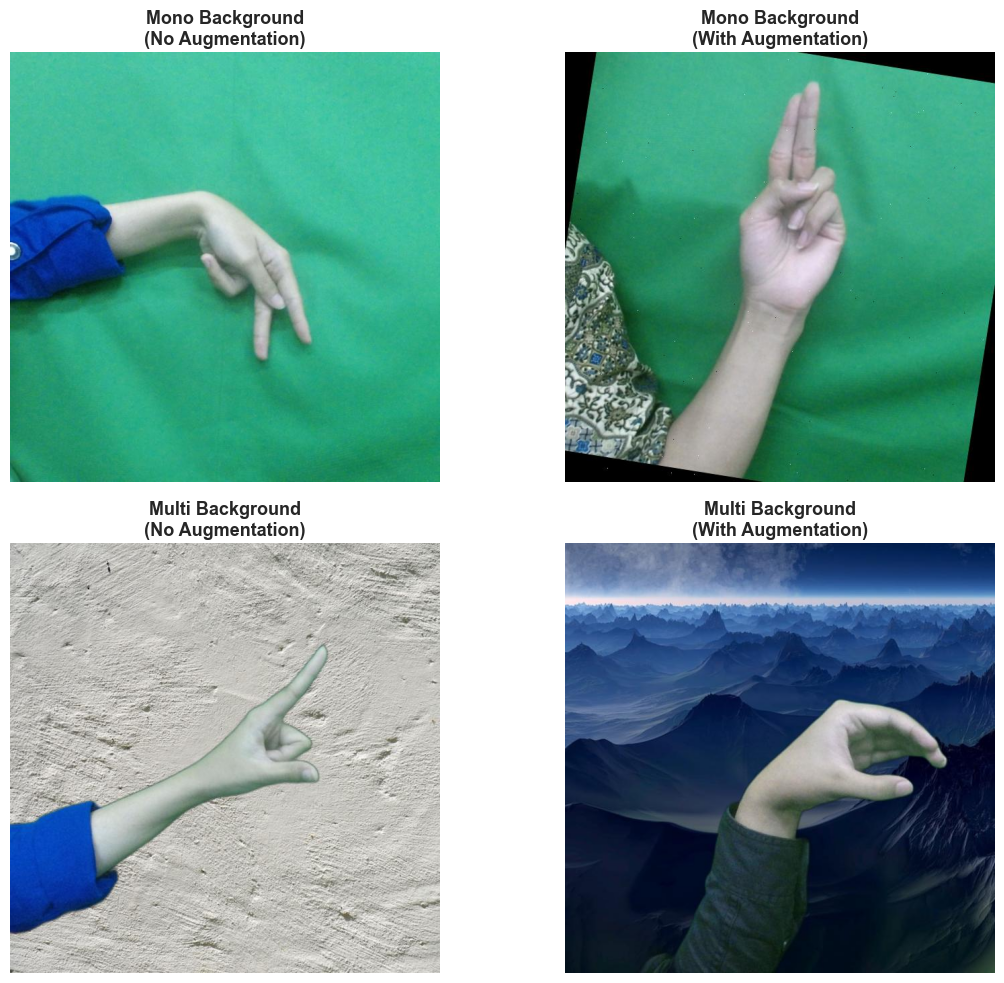

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Judul untuk masing-masing subplot
titles = [
    'Mono Background\n(No Augmentation)', 
    'Mono Background\n(With Augmentation)',
    'Multi Background\n(No Augmentation)', 
    'Multi Background\n(With Augmentation)'
]

for i, ds in enumerate(datasets):
    # Cari gambar acak di folder train masing-masing dataset
    img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', 'train')
    
    # Pencarian rekursif untuk mencari gambar acak
    all_imgs = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    all_imgs = [f for f in all_imgs if os.path.isfile(f)]
    
    if all_imgs:
        random_img_path = random.choice(all_imgs)
        
        # Baca gambar dan konversi BGR (OpenCV) ke RGB (Matplotlib)
        img = cv2.imread(random_img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)
        else:
            axes[i].text(0.5, 0.5, 'Gagal memuat gambar', ha='center')
            
        axes[i].set_title(titles[i], fontsize=13, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Gambar tidak ditemukan', ha='center', color='red')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

plt.tight_layout()
plt.show()


## **6. Validasi Kemunculan Tangan (*Landmark Detection*)**
Menggunakan *framework* MediaPipe (Google) untuk memastikan bahwa objek yang ada di dalam citra benar-benar dapat dideteksi sebagai struktur anatomis tangan manusia. Langkah ini menunjukkan kelayakan gambar untuk digunakan dalam pemodelan klasifikasi bahasa isyarat.


In [7]:
# Install modul MediaPipe secara otomatis jika belum ada (opsional jika sudah berjalan di env lokal)
import sys
!{sys.executable} -m pip install protobuf==3.20.3 mediapipe -q

import mediapipe as mp

# Inisialisasi model MediaPipe Hands untuk gambar statis
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

hands = mp_hands.Hands(
    static_image_mode=True, 
    max_num_hands=1, 
    min_detection_confidence=0.5
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Kita bandingkan sample dari Mono BG vs Multi BG
sample_folders = [
    os.path.join(BASE_DATA_DIR, datasets[0], 'images', 'train'), # Mono
    os.path.join(BASE_DATA_DIR, datasets[2], 'images', 'train')  # Multi
]

titles_mp = ['Deteksi pada Mono Background', 'Deteksi pada Multi Background']

for i, folder in enumerate(sample_folders):
    all_imgs = glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
    all_imgs = [f for f in all_imgs if os.path.isfile(f)]
    
    if all_imgs:
        img_path = random.choice(all_imgs)
        image = cv2.imread(img_path)
        
        if image is not None:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Proses inferensi MediaPipe
            results = hands.process(image_rgb)
            
            # Jika landmark tangan ditemukan, gambar titik dan garisnya
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    mp_drawing.draw_landmarks(
                        image_rgb, 
                        hand_landmarks, 
                        mp_hands.HAND_CONNECTIONS,
                        mp_drawing_styles.get_default_hand_landmarks_style(),
                        mp_drawing_styles.get_default_hand_connections_style()
                    )
                axes[i].set_title(f"{titles_mp[i]}\n(Status: Berhasil Terdeteksi ✅)", color='darkgreen', fontweight='bold', pad=10)
            else:
                axes[i].set_title(f"{titles_mp[i]}\n(Status: Gagal Terdeteksi ❌)", color='darkred', fontweight='bold', pad=10)
                
            axes[i].imshow(image_rgb)
            axes[i].axis('off')
    else:
        axes[i].set_title(f"{titles_mp[i]}\n(Folder Kosong)", color='red')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

hands.close()  # Bersihkan resource



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


AttributeError: module 'mediapipe' has no attribute 'solutions'

## **7. Analisis Spasial Bounding Box (Heatmap)**
Mengetahui di area mana tangan paling sering difokuskan atau diletakkan di dalam *frame* (gambar). Data ini diambil dengan mengekstrak titik tengah (*center*) X dan Y dari label format YOLO.


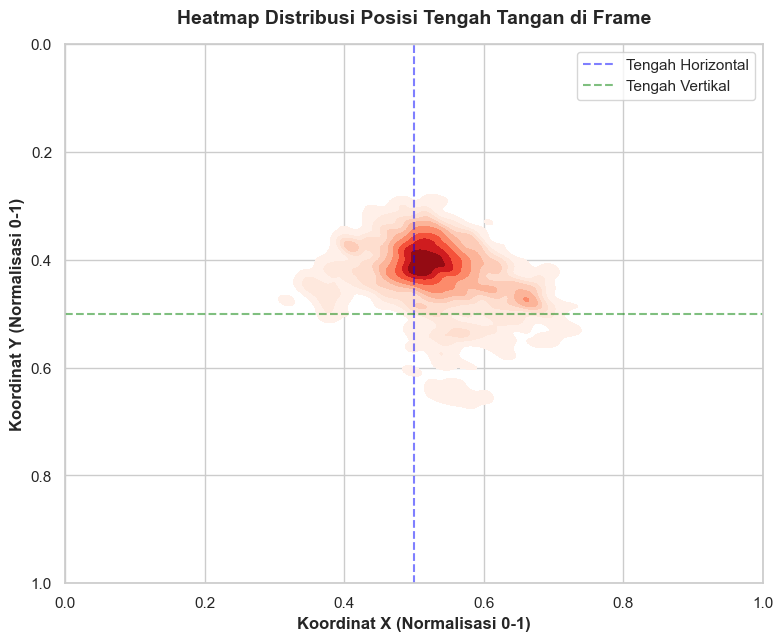

In [8]:
# Menggunakan dataset mono background sebagai acuan heatmap
target_label_dir = os.path.join(BASE_DATA_DIR, datasets[0], 'labels', 'train')
label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
label_files = [f for f in label_files if os.path.isfile(f)]

x_centers = []
y_centers = []

for txt_file in label_files:
    with open(txt_file, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                # Format YOLO: <class> <x_center> <y_center> <width> <height>
                try:
                    x_c = float(parts[1])
                    y_c = float(parts[2])
                    x_centers.append(x_c)
                    y_centers.append(y_c)
                except ValueError:
                    continue

plt.figure(figsize=(9, 7))

# Membuat 2D KDE Plot (Heatmap)
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, thresh=0.05, bw_adjust=0.5)

plt.title('Heatmap Distribusi Posisi Tengah Tangan di Frame', fontweight='bold', fontsize=14, pad=15)
plt.xlabel('Koordinat X (Normalisasi 0-1)', fontweight='bold')
plt.ylabel('Koordinat Y (Normalisasi 0-1)', fontweight='bold')

# Set limit dari 0 sampai 1 karena koordinat YOLO sudah dinormalisasi terhadap ukuran asli
plt.xlim(0, 1)
plt.ylim(1, 0) # Dibalik karena titik origin (0,0) pada gambar digital ada di pojok kiri atas

# Garis bantu titik tengah frame
plt.axvline(0.5, color='blue', linestyle='--', alpha=0.5, label='Tengah Horizontal')
plt.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='Tengah Vertikal')

plt.legend()
plt.show()


## **8. Analisis Intensitas Pencahayaan (Brightness Level)**
Mengukur sebaran tingkat kecerahan gambar untuk memastikan apakah variansi pencahayaan (gelap/terang) pada dataset cukup mewakili kondisi nyata (*real-world constraints*).


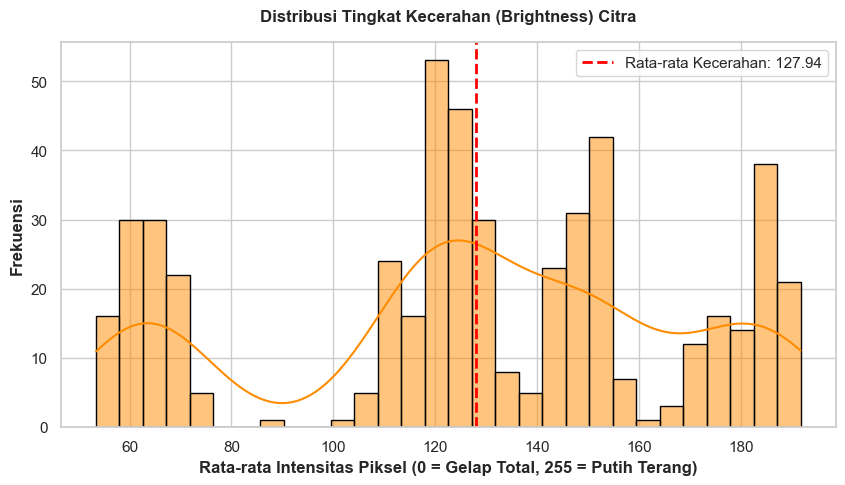

In [9]:
def calculate_brightness(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    
    # Konversi ke Grayscale untuk menghitung rata-rata intensitas iluminasi piksel
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

brightness_levels = []
sample_img_dir = os.path.join(BASE_DATA_DIR, datasets[2], 'images', 'train') # Gunakan Multi BG
all_imgs = glob.glob(os.path.join(sample_img_dir, '**', '*.*'), recursive=True)
all_imgs = [f for f in all_imgs if os.path.isfile(f)]

# Ambil 500 sampel agar komputasi lebih ringan
sample_size_bright = min(500, len(all_imgs))
if sample_size_bright > 0:
    sample_files = random.sample(all_imgs, sample_size_bright)
    
    for img_path in sample_files:
        bright_val = calculate_brightness(img_path)
        if bright_val is not None:
            brightness_levels.append(bright_val)

    plt.figure(figsize=(10, 5))
    sns.histplot(brightness_levels, bins=30, kde=True, color='darkorange', edgecolor='black')
    plt.title('Distribusi Tingkat Kecerahan (Brightness) Citra', fontweight='bold', pad=15)
    plt.xlabel('Rata-rata Intensitas Piksel (0 = Gelap Total, 255 = Putih Terang)', fontweight='bold')
    plt.ylabel('Frekuensi', fontweight='bold')
    
    mean_bright = np.mean(brightness_levels)
    plt.axvline(mean_bright, color='red', linestyle='--', linewidth=2, 
                label=f'Rata-rata Kecerahan: {mean_bright:.2f}')
    
    plt.legend()
    plt.show()
else:
    print("Tidak dapat menganalisis kecerahan. Gambar tidak ditemukan.")


## **9. Kesimpulan Exploratory Data Analysis (EDA)**

Dari rangkaian eksplorasi data di atas, dapat ditarik beberapa kesimpulan penting untuk panduan penulisan skripsi:

1. **Integritas Data:** Jumlah *file* gambar dan label berformat YOLO (`.txt`) telah tervalidasi selaras, tidak ada perbedaan atau anomali data yang hilang, siap digunakan pada *pipeline preprocessing*.
2. **Keseimbangan Kelas:** Dataset menunjukkan tingkat distribusi yang baik untuk masing-masing kelas (huruf SIBI). Model diyakini tidak akan mengalami *bias* berlebih.
3. **Dimensi Citra:** Teridentifikasi resolusi mayoritas yang dapat dijadikan acuan utama saat melakukan proses *resizing* di lapisan *Data Loader*.
4. **Variasi Lingkungan & Augmentasi:** Pembagian antara *Mono/Multi Background* dan *Augmentasi* terbukti memberikan keragaman karakteristik. *Multi background* mensimulasikan kasus dunia nyata (*real-world noise*) sementara augmentasi memperkaya data latih.
5. **Analisis Spasial:** Bounding box objek terpusat di tengah gambar (terlihat pada Heatmap), membuktikan bahwa teknik pemotongan (*cropping*) atau *focal attention* pada pusat *frame* sangat mungkin meningkatkan performa.
6. **Robustness Pencahayaan:** Distribusi spektrum *brightness* yang terukur mengindikasikan bahwa model akan berlatih pada kondisi rentang cahaya yang variatif.

**Langkah Selanjutnya (Next Steps):**
Membangun arsitektur *Deep Learning* (seperti YOLOv8, ResNet, atau CNN kustom) dan menyusun *pipeline training*.
